In [ ]:
# Cell 1: Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

sales_data = pd.read_csv('https://www.statlearning.com/s/Advertising.csv', index_col=0)

# Exercise 1
### Visualize data as a heatmap and in another way of your choosing.

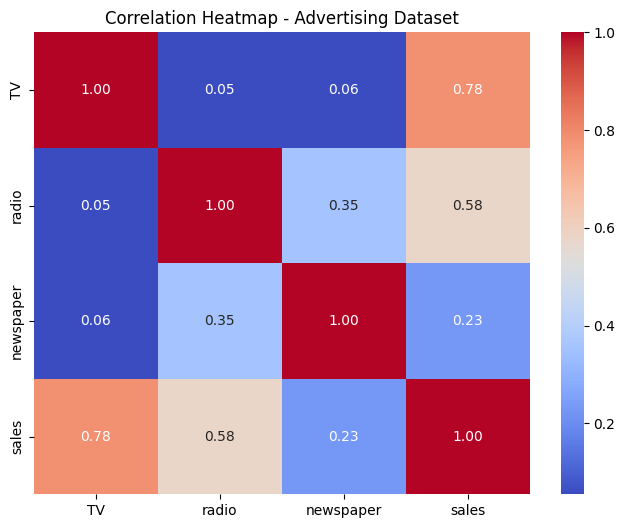

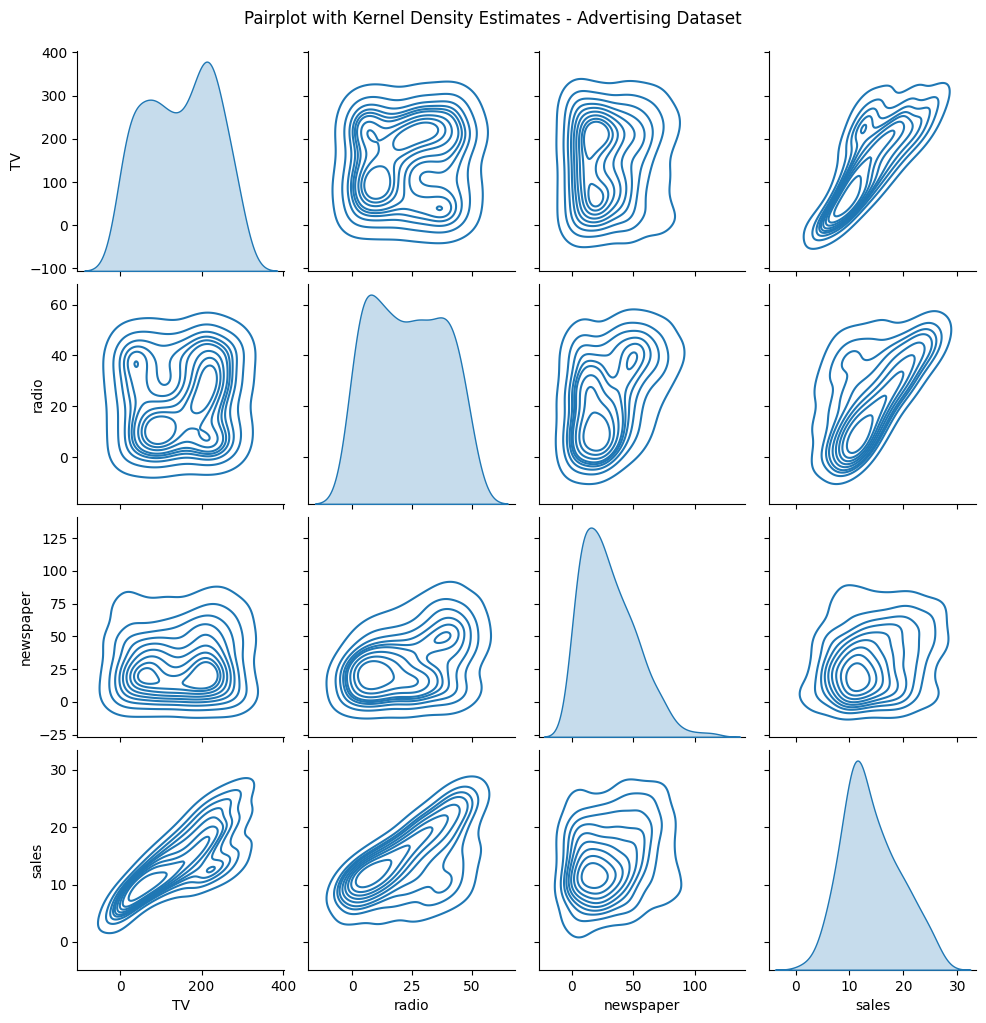

<Figure size 800x600 with 0 Axes>

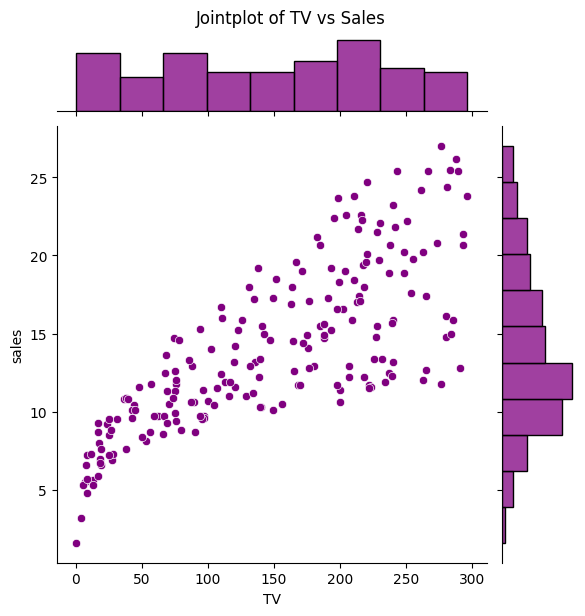

In [ ]:
# Cell 2: Data Visualization
# Possible solutions:

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(sales_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Advertising Dataset')
plt.show()

# Pairplot
sns.pairplot(sales_data, kind='kde')
plt.suptitle('Pairplot with Kernel Density Estimates - Advertising Dataset', y=1.02)
plt.show()

# Jointplot of TV vs Sales
plt.figure(figsize=(8, 6))
sns.jointplot(x='TV', y='sales', data=sales_data, kind='scatter', color='purple')
plt.suptitle('Jointplot of TV vs Sales', y=1.02)
plt.show()

### a) Fit a simple linear regression model of every advertisement medium and print their summaries. (You should also try to understand them.)
### Hint: Don't forget to split the data into training and test sets!
### b) Fit a multiple linear regression model and print the summary

In [ ]:
# Cell 3: Fitting simple linear regression models
# and printing summary statistics; use simple train / test split

# Define predictors and response for simple regression
X_simple1 = sm.add_constant(sales_data[['TV']])
X_simple2 = sm.add_constant(sales_data[['radio']])
X_simple3 = sm.add_constant(sales_data[['newspaper']])
y = sales_data['sales']

# Split data into training and test sets
X_train_s1, X_test_s1, y_train_s1, y_test_s1 = train_test_split(X_simple1, y, test_size=0.2, random_state=42)

# Fit simple linear regression model
model_simple_TV = sm.OLS(y_train_s1, X_train_s1).fit()
y_pred_simple_TV = model_simple_TV.predict(X_test_s1)

# Evaluate and compare models
print('\nSimple Linear Regression (TV only):')
print(model_simple_TV.summary())

# Split data into training and test sets
X_train_s2, X_test_s2, y_train_s2, y_test_s2 = train_test_split(X_simple2, y, test_size=0.2, random_state=42)

# Fit simple linear regression model
model_simple_radio = sm.OLS(y_train_s2, X_train_s2).fit()
y_pred_simple_radio = model_simple_radio.predict(X_test_s2)

# Evaluate and compare models
print('\nSimple Linear Regression (radio only):')
print(model_simple_radio.summary())

# Split data into training and test sets
X_train_s3, X_test_s3, y_train_s3, y_test_s3 = train_test_split(X_simple3, y, test_size=0.2, random_state=42)

# Fit simple linear regression model
model_simple_paper = sm.OLS(y_train_s3, X_train_s3).fit()
y_pred_simple_paper = model_simple_paper.predict(X_test_s3)

# Evaluate and compare models
print('\nSimple Linear Regression (newspaper only):')
print(model_simple_paper.summary())


Simple Linear Regression (TV only):
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.591
Model:                            OLS   Adj. R-squared:                  0.589
Method:                 Least Squares   F-statistic:                     228.5
Date:                Tue, 29 Apr 2025   Prob (F-statistic):           1.68e-32
Time:                        20:30:42   Log-Likelihood:                -415.93
No. Observations:                 160   AIC:                             835.9
Df Residuals:                     158   BIC:                             842.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          

### 1\. Relationship between budget and sales

In [ ]:
# Cell 4: Fitting multiple linear regression model
# and printing summary statistics; use simple train / test split

# Define predictors and response for multiple regression (TV, Radio, Newspaper)
X_multiple = sm.add_constant(sales_data[['TV', 'radio', 'newspaper']])

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multiple, y, test_size=0.2, random_state=42)

# Fit multiple linear regression model
model_multiple = sm.OLS(y_train_m, X_train_m).fit()
y_pred_multiple = model_multiple.predict(X_test_m)

print('\nMultiple Linear Regression (TV, Radio, Newspaper):')
print(model_multiple.summary())


Multiple Linear Regression (TV, Radio, Newspaper):
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.894
Method:                 Least Squares   F-statistic:                     446.6
Date:                Tue, 29 Apr 2025   Prob (F-statistic):           2.53e-76
Time:                        20:30:43   Log-Likelihood:                -306.64
No. Observations:                 160   AIC:                             621.3
Df Residuals:                     156   BIC:                             633.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------


### a) Visualize any one of the simple linear regression models and the multiple linear regression model as plots

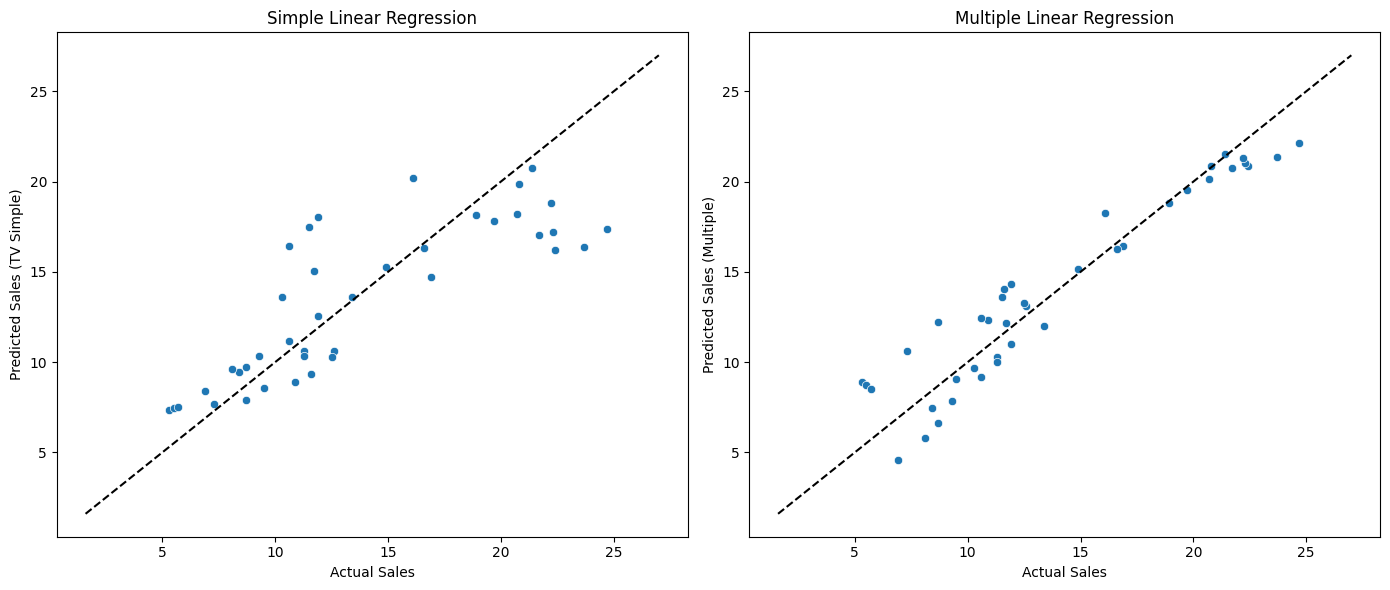

In [ ]:
# Cell 5: Result visualization via scatter plots

# Visualize actual vs predicted for both models
_, axs = plt.subplots(1, 2, figsize=(14, 6))

# Simple regression plot
sns.scatterplot(x=y_test_s1, y=y_pred_simple_TV, ax=axs[0])
axs[0].set_xlabel('Actual Sales')
axs[0].set_ylabel('Predicted Sales (TV Simple)')
axs[0].set_title('Simple Linear Regression')
axs[0].plot([y.min(), y.max()], [y.min(), y.max()], 'k--')

# Multiple regression plot
sns.scatterplot(x=y_test_m, y=y_pred_multiple, ax=axs[1])
axs[1].set_xlabel('Actual Sales')
axs[1].set_ylabel('Predicted Sales (Multiple)')
axs[1].set_title('Multiple Linear Regression')
axs[1].plot([y.min(), y.max()], [y.min(), y.max()], 'k--')

plt.tight_layout()
plt.show()

### Fit the TV sales into a polynomial regression model with degree=4, print the summary and visualize the model as a plot


Polynomial Regression:
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.596
Method:                 Least Squares   F-statistic:                     59.55
Date:                Tue, 29 Apr 2025   Prob (F-statistic):           2.23e-30
Time:                        20:30:43   Log-Likelihood:                -413.01
No. Observations:                 160   AIC:                             836.0
Df Residuals:                     155   BIC:                             851.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.8224      1

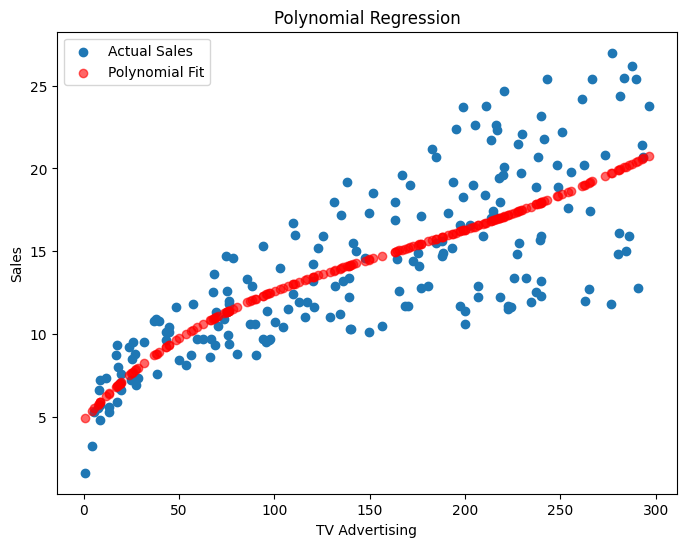

In [ ]:
# Cell 6: Explore generalized (polynomial) linear regression

# Demonstrating Overfitting with Polynomial Regression
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(sales_data[['TV']])

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y, test_size=0.2, random_state=42)

# Fit polynomial regression model
poly_model = sm.OLS(y_train_poly, X_train_poly).fit()
y_pred_poly_train = poly_model.predict(X_train_poly)
y_pred_poly_test = poly_model.predict(X_test_poly)

# Evaluate polynomial regression
print('\nPolynomial Regression:')
print(poly_model.summary())

# Visualize
plt.figure(figsize=(8, 6))
plt.scatter(sales_data['TV'], y, label='Actual Sales')
plt.scatter(sales_data['TV'], poly_model.predict(X_poly), color='red', label='Polynomial Fit', alpha=0.6)
plt.xlabel('TV Advertising')
plt.ylabel('Sales')
plt.title('Polynomial Regression')
plt.legend()
plt.show()

# Exercise 2 (additional cells)


In [ ]:
# Cell 7: Calculate and print correlation coefficients and p-values
# for the given data

import numpy as np
from scipy import stats

# Correlation matrix and two‑sided p‑values
def corr_p(df):
    cols = df.columns
    n = len(cols)
    r = pd.DataFrame(index=cols, columns=cols, dtype=float)
    p = pd.DataFrame(index=cols, columns=cols, dtype=float)
    for i in range(n):
        for j in range(n):
            r.iloc[i, j], p.iloc[i, j] = stats.pearsonr(df[cols[i]], df[cols[j]])
    return r, p

corr, pvals = corr_p(sales_data)
print("Correlation coefficients:\n", corr.round(3))
print("\nCorresponding p‑values:\n", pvals.round(3))

Correlation coefficients:
               TV  radio  newspaper  sales
TV         1.000  0.055      0.057  0.782
radio      0.055  1.000      0.354  0.576
newspaper  0.057  0.354      1.000  0.228
sales      0.782  0.576      0.228  1.000

Corresponding p‑values:
               TV  radio  newspaper  sales
TV         0.000  0.441      0.426  0.000
radio      0.441  0.000      0.000  0.000
newspaper  0.426  0.000      0.000  0.001
sales      0.000  0.000      0.001  0.000


In [ ]:
# Cell 8: Define a helper function to calculate RMSE and R-squared

from sklearn.metrics import mean_squared_error, r2_score

# helper to report metrics

def report(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{model_name}:  RMSE = {rmse:.3f},  R² = {r2:.3f}")

In [ ]:
# Cell 9: Evaluate the performance of the simple, multiple and
# polynomial regression models on the test set using the helper function

print("\n---- Generalisation performance ----")
report("Simple TV",    y_test_s1,  y_pred_simple_TV)
report("Simple radio", y_test_s2,  y_pred_simple_radio)
report("Simple paper", y_test_s3,  y_pred_simple_paper)
report("Multiple",     y_test_m,   y_pred_multiple)
report("Poly‑deg4",    y_test_poly, y_pred_poly_test)


---- Generalisation performance ----
Simple TV:  RMSE = 3.194,  R² = 0.677
Simple radio:  RMSE = 4.822,  R² = 0.263
Simple paper:  RMSE = 5.534,  R² = 0.030
Multiple:  RMSE = 1.782,  R² = 0.899
Poly‑deg4:  RMSE = 3.219,  R² = 0.672


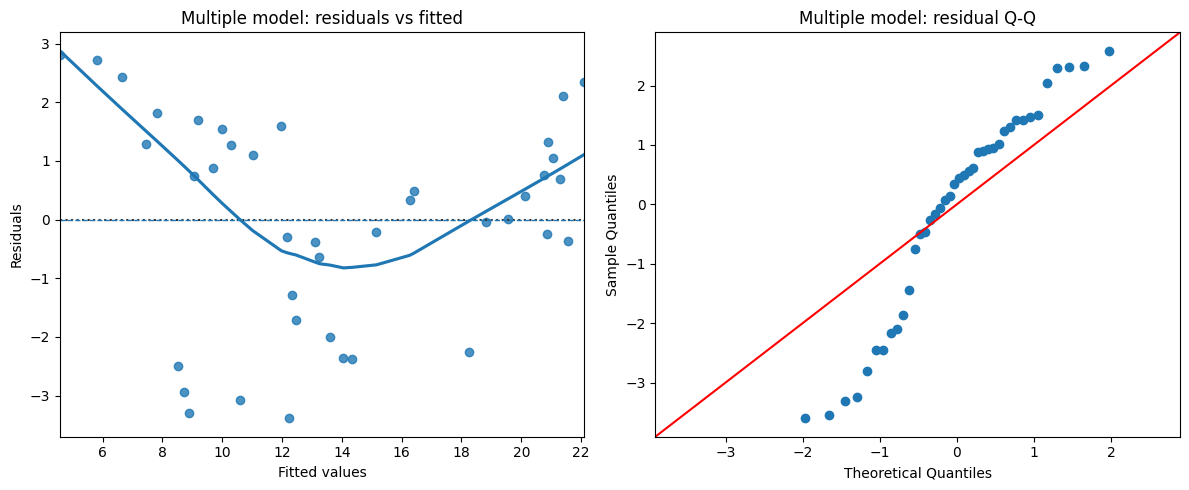

In [ ]:
# Cell 10: Analyze the residuals of the multiple linear regression model
# by creating a residuals vs. fitted plot and a normal Q-Q plot to assess
# the model's assumptions

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Residuals vs fitted
sns.residplot(x=y_pred_multiple, y=y_test_m - y_pred_multiple, lowess=True, ax=axes[0])
axes[0].axhline(0, ls='--', lw=1)
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Multiple model: residuals vs fitted')

# Normal Q‑Q plot
sm.qqplot(y_test_m - y_pred_multiple, line='45', ax=axes[1])
axes[1].set_title('Multiple model: residual Q‑Q')
plt.tight_layout()
plt.show()

In [ ]:
# Cell 11: explores interaction terms in the multiple linear regression model
# by creating interaction terms obtained from multiplying predictor variables,
# fitting a new model with interaction terms and printing its summary statistics.
# Evaluate the performance of the interaction model using the helper function.

# Add interaction terms
data_int = sales_data.copy()
data_int['TV_radio']      = data_int['TV']  * data_int['radio']
data_int['TV_newspaper']  = data_int['TV']  * data_int['newspaper']
data_int['radio_newsp']   = data_int['radio'] * data_int['newspaper']

X_int = sm.add_constant(data_int[['TV', 'radio', 'newspaper',
                                  'TV_radio', 'TV_newspaper', 'radio_newsp']])
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_int, y, test_size=0.2, random_state=42)

model_int = sm.OLS(y_train_i, X_train_i).fit()
print(model_int.summary())

# test performance
y_pred_i = model_int.predict(X_test_i)
report("Interaction", y_test_i, y_pred_i)

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                     733.8
Date:                Tue, 29 Apr 2025   Prob (F-statistic):          5.05e-110
Time:                        20:30:44   Log-Likelihood:                -215.99
No. Observations:                 160   AIC:                             446.0
Df Residuals:                     153   BIC:                             467.5
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            6.3105      0.372     16.976   

In [ ]:
# Cell 12: Make predictions with the multiple linear regression model
# for a new observation and also compute confidence intevals for the
# new prediction

# --- Build the new-data row with the same 4 columns -----------------
new_obs = pd.DataFrame(
    {"TV": [150],
     "radio": [25],
     "newspaper": [15]}
)

# add the intercept column *and* keep column order consistent
new_obs = sm.add_constant(new_obs, has_constant='add')
# new_obs.columns → ['const', 'TV', 'radio', 'newspaper']

# --- Get predictions ------------------------------------------------
pred_res = model_multiple.get_prediction(new_obs)
pred_df  = pred_res.summary_frame(alpha=0.05)   # 95 % intervals

pred_df[['mean', 'mean_ci_lower', 'mean_ci_upper',
         'obs_ci_lower',  'obs_ci_upper']]


,mean,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,14.459788,14.11458,14.804996,11.15153,17.768046


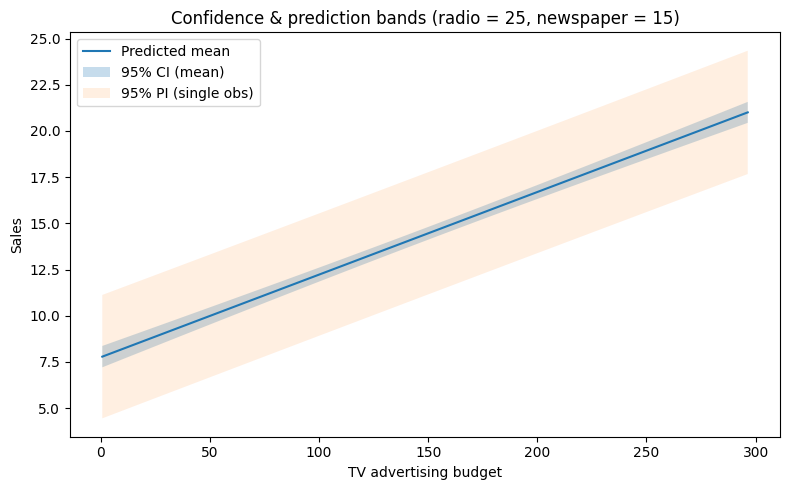

In [ ]:
# Cell 13: Visualize the confidence and prediction bands for the
# multiple linear regression model.

# --- Build a TV grid while holding radio & newspaper fixed --------------
tv_grid = np.linspace(sales_data.TV.min(), sales_data.TV.max(), 100)
grid = pd.DataFrame({
    "TV": tv_grid,
    "radio": 25,          # fixed value (change if you like)
    "newspaper": 15
})

# --- Add the intercept and reorder --------------------------------------
grid_c = sm.add_constant(grid, has_constant='add')     # adds column 'const'
grid_c = grid_c[model_multiple.model.exog_names]       # ensure exact order
# grid_c.columns → ['const', 'TV', 'radio', 'newspaper']

# --- Get predictions -----------------------------------------------------
grid_pred = model_multiple.get_prediction(grid_c).summary_frame(alpha=0.05)

# --- Plot ---------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(tv_grid, grid_pred['mean'], label='Predicted mean')
plt.fill_between(tv_grid,
                 grid_pred['mean_ci_lower'], grid_pred['mean_ci_upper'],
                 alpha=0.25, label='95% CI (mean)')
plt.fill_between(tv_grid,
                 grid_pred['obs_ci_lower'], grid_pred['obs_ci_upper'],
                 alpha=0.12, label='95% PI (single obs)')
plt.xlabel('TV advertising budget')
plt.ylabel('Sales')
plt.title('Confidence & prediction bands (radio = 25, newspaper = 15)')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Cell 14: Calculate the Residual Standard Error (RSE) for the
# multiple linear regression model.

import numpy as np
import statsmodels.api as sm

X = sm.add_constant(sales_data[['TV', 'radio', 'newspaper']])
y = sales_data['sales']

model = sm.OLS(y, X).fit()

rse_builtin = np.sqrt(model.scale)      # model.scale == RSS / df_resid
print("RSE (built-in):", rse_builtin)

# Compute manually for illustration
rss = np.sum(model.resid ** 2)
df_resid = model.df_resid              # equals n - p - 1
rse_manual = np.sqrt(rss / df_resid)
print("RSE (manual) :", rse_manual)


RSE (built-in): 1.6855103734147439
RSE (manual) : 1.685510373414744
